# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** ______________ &nbsp; **학번:** ______________ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: `final_dataset_descriptors.csv` (Template 1 출력)
- **출력**:
  - `experiment_results.csv` — 전체 실험 결과 표
  - `experiment_best.csv` — 모델별 최고 결과
  - `model_best.joblib` — 최고 모델 저장

---

## 1. 라이브러리 불러오기

In [19]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')
from rdkit.Chem import AllChem, MACCSkeys, Descriptors

from sklearn.ensemble import (ExtraTreesClassifier, ExtraTreesRegressor,
                               HistGradientBoostingClassifier,
                               HistGradientBoostingRegressor)
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                              confusion_matrix, r2_score, mean_squared_error)
from sklearn.feature_selection import VarianceThreshold
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import matplotlib.font_manager as fm
def _set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available: return font
    return 'DejaVu Sans'
matplotlib.rcParams['font.family'] = _set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')


라이브러리 로드 완료


## 2. 데이터 로드 및 Feature Matrix 복원

`final_dataset_descriptors.csv`를 읽어 각 디스크립터 행렬을 복원합니다.

In [20]:
df_desc = pd.read_csv('final_dataset_descriptors.csv')
print(f'로드 완료: {df_desc.shape}')

morgan_cols = [c for c in df_desc.columns if c.startswith('Morgan_')]
maccs_cols  = [c for c in df_desc.columns if c.startswith('MACCS_')]
ap_cols     = [c for c in df_desc.columns if c.startswith('AP_')]
tor_cols    = [c for c in df_desc.columns if c.startswith('Tor_')]
phys_cols   = [c for c in df_desc.columns
               if c not in (['SMILES','label','logLD50']
                             + morgan_cols + maccs_cols + ap_cols + tor_cols)]

X_morgan = df_desc[morgan_cols].values.astype(np.float32)
X_maccs  = df_desc[maccs_cols].values.astype(np.float32)
X_ap     = df_desc[ap_cols].values.astype(np.float32)
X_tor    = df_desc[tor_cols].values.astype(np.float32)
X_phys   = df_desc[phys_cols].values.astype(np.float32)

y_clf = df_desc['label'].values.astype(int)
y_reg = df_desc['logLD50'].values.astype(float)

print(f'Morgan FP     : {X_morgan.shape}')
print(f'MACCS Keys    : {X_maccs.shape}')
print(f'AtomPair FP   : {X_ap.shape}')
print(f'Torsion FP    : {X_tor.shape}')
print(f'RDKit Desc    : {X_phys.shape}')
print(f'y_clf: {y_clf.sum()}개 독성 / {(y_clf==0).sum()}개 비독성')
print(f'y_reg: logLD50 {y_reg.min():.2f} ~ {y_reg.max():.2f}')


로드 완료: (6388, 6531)
Morgan FP     : (6388, 2048)
MACCS Keys    : (6388, 167)
AtomPair FP   : (6388, 2048)
Torsion FP    : (6388, 2048)
RDKit Desc    : (6388, 217)
y_clf: 1709개 독성 / 4679개 비독성
y_reg: logLD50 -1.92 ~ 4.85


## 3. 데이터 분할  (80% Train+Val / 20% Test)

In [21]:
idx = np.arange(len(y_clf))
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y_clf)

y_clf_tv   = y_clf[idx_trainval];  y_clf_test = y_clf[idx_test]
y_reg_tv   = y_reg[idx_trainval];  y_reg_test = y_reg[idx_test]
scale_pos_weight = float((y_clf_tv==0).sum()) / float((y_clf_tv==1).sum())

print(f'Train+Val : {len(idx_trainval)}개  독성={y_clf_tv.sum()} ({y_clf_tv.mean():.1%})')
print(f'Test      : {len(idx_test)}개  독성={y_clf_test.sum()} ({y_clf_test.mean():.1%})')
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

Train+Val : 5110개  독성=1367 (26.8%)
Test      : 1278개  독성=342 (26.8%)
scale_pos_weight = 2.74


## 4. 디스크립터 정제 (분산=0 + 상관 |r|>0.95 제거)

In [22]:
var_sel   = VarianceThreshold(threshold=0.0)
X_phys_tv = var_sel.fit_transform(X_phys[idx_trainval])
corr_matrix = np.corrcoef(X_phys_tv.T)
upper       = np.triu(np.abs(corr_matrix), k=1)
drop_cols   = set(int(i) for i in np.where((upper > 0.95).any(axis=0))[0])
keep_cols   = [i for i in range(X_phys_tv.shape[1]) if i not in drop_cols]
X_phys_clean = var_sel.transform(X_phys)[:, keep_cols]
print(f'RDKit Desc 정제: {X_phys.shape[1]} → {X_phys_clean.shape[1]}개')

RDKit Desc 정제: 217 → 187개


---
## Part A. 이진 분류 모델 (Acute Oral Toxicity)

**목표**: LD50 ≤ 300 mg/kg → 독성(1), > 300 → 비독성(0)  
**평가 지표**: Balanced Accuracy (주), ROC-AUC, Sensitivity, Specificity

### 5-A. 모델 학습 및 5-Fold CV 비교

In [23]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True)

# 디스크립터 — 개별(5종) + 조합(4종)
# 개별 성능을 먼저 확인하여 어떤 디스크립터가 유효한지 판단
descriptors_clf = {
    # ── 개별 디스크립터 ──────────────────────────────────────
    'Morgan only'   : X_morgan,
    'MACCS only'    : X_maccs,
    'AtomPair only' : X_ap,
    'Torsion only'  : X_tor,
    'RDKit Desc'    : X_phys_clean,
    # ── 조합 디스크립터 ──────────────────────────────────────
    'All4FP+CleanDesc'   : np.hstack([X_morgan, X_maccs, X_ap, X_tor, X_phys_clean]),
    'Morgan+MACCS+Desc'  : np.hstack([X_morgan, X_maccs, X_phys_clean]),
    'All4FP (FP only)'   : np.hstack([X_morgan, X_maccs, X_ap, X_tor]),
    'Morgan+MACCS'       : np.hstack([X_morgan, X_maccs]),
}

# 모델 정의 (4종 알고리즘)
models_clf = {
    # SVM (Pipeline: StandardScaler 포함)
    'SVM'         : Pipeline([('scaler', StandardScaler()),
                               ('clf', SVC(C=1.0, kernel='rbf',
                                           class_weight='balanced', probability=True))]),
    # MLP (2-hidden-layer)
    'MLP'         : Pipeline([('scaler', StandardScaler()),
                               ('clf', MLPClassifier(hidden_layer_sizes=(256, 128),
                                                     max_iter=300, early_stopping=True))]),
    # KNN
    'KNN'         : Pipeline([('scaler', StandardScaler()),
                               ('clf', KNeighborsClassifier(n_neighbors=7,
                                                             weights='distance', n_jobs=-1))]),
    # XGBoost
    'XGBoost'     : XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                   scale_pos_weight=scale_pos_weight,
                                   subsample=0.8, colsample_bytree=0.8,
                                   n_jobs=-1, verbosity=0, eval_metric='logloss'),
    # ExtraTrees
    'ExtraTrees'  : ExtraTreesClassifier(n_estimators=200, class_weight='balanced',
                                          max_features='sqrt', n_jobs=-1),
    # HistGradBoost
    'HistGradBoost': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                     max_depth=6),
}

results_clf = []
total = len(descriptors_clf) * len(models_clf); done = 0
for dname, X_d in descriptors_clf.items():
    X_tv = X_d[idx_trainval]
    for mname, model in models_clf.items():
        scores = cross_val_score(model, X_tv, y_clf_tv, cv=cv_clf,
                                 scoring='balanced_accuracy', n_jobs=-1)
        results_clf.append({'Descriptor': dname, 'Model': mname,
                            'Mean_BalAcc': scores.mean(), 'Std': scores.std()})
        done += 1
        print(f'[{done:2d}/{total}] {dname:30s} | {mname:18s} | BalAcc={scores.mean():.4f}±{scores.std():.4f}')

results_clf_df = pd.DataFrame(results_clf).sort_values('Mean_BalAcc', ascending=False).reset_index(drop=True)
print('\n=== Top 5 ===')
print(results_clf_df.head(5).to_string(index=False))

[ 1/54] Morgan only                    | SVM                | BalAcc=0.7242±0.0137
[ 2/54] Morgan only                    | MLP                | BalAcc=0.6834±0.0272
[ 3/54] Morgan only                    | KNN                | BalAcc=0.5882±0.0142
[ 4/54] Morgan only                    | XGBoost            | BalAcc=0.7424±0.0205
[ 5/54] Morgan only                    | ExtraTrees         | BalAcc=0.7299±0.0164
[ 6/54] Morgan only                    | HistGradBoost      | BalAcc=0.6953±0.0160
[ 7/54] MACCS only                     | SVM                | BalAcc=0.7666±0.0143
[ 8/54] MACCS only                     | MLP                | BalAcc=0.7139±0.0112
[ 9/54] MACCS only                     | KNN                | BalAcc=0.7177±0.0080
[10/54] MACCS only                     | XGBoost            | BalAcc=0.7630±0.0186
[11/54] MACCS only                     | ExtraTrees         | BalAcc=0.7394±0.0145
[12/54] MACCS only                     | HistGradBoost      | BalAcc=0.7161±0.0149
[13/

### 5-A-2. CV 결과 시각화 (Fig. A-1)

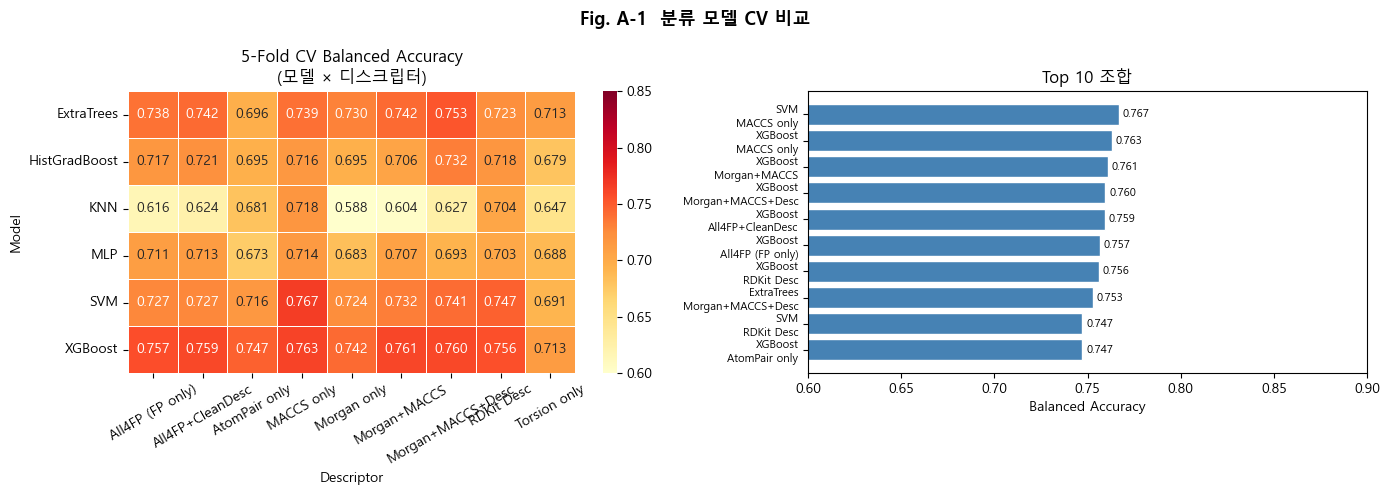

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히트맵
pivot = results_clf_df.pivot_table(index='Model', columns='Descriptor', values='Mean_BalAcc')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.6, vmax=0.85,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('5-Fold CV Balanced Accuracy\n(모델 × 디스크립터)', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# Top 10 막대
top10 = results_clf_df.head(10)
colors = ['tomato' if v >= 0.78 else 'steelblue' for v in top10['Mean_BalAcc']]
bars = axes[1].barh(range(len(top10)),  top10['Mean_BalAcc'], color=colors, edgecolor='white')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels([f"{r['Model']}\n{r['Descriptor'][:20]}" for _, r in top10.iterrows()], fontsize=8)
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('Top 10 조합')
axes[1].invert_yaxis()
axes[1].set_xlim(0.6, 0.9)
for bar, v in zip(bars, top10['Mean_BalAcc']):
    axes[1].text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('Fig. A-1  분류 모델 CV 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 6-A. Optuna 하이퍼파라미터 최적화 (분류 — XGB + ExtraTrees)

CV 1위 디스크립터 조합에서 XGBoost와 ExtraTrees의 하이퍼파라미터를 **Bayesian 최적화(TPE)**로 탐색합니다.


In [27]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

top_clf_desc   = results_clf_df.iloc[0]['Descriptor']
X_optuna_clf   = descriptors_clf[top_clf_desc][idx_trainval]
cv_optuna_clf  = StratifiedKFold(n_splits=5, shuffle=True)

# ── XGBoost Optuna ─────────────────────────────────────────────────────
def xgb_clf_obj(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'scale_pos_weight': scale_pos_weight, 'n_jobs': -1, 'verbosity': 0,
        'eval_metric': 'logloss',
    }
    scores = cross_val_score(XGBClassifier(**params), X_optuna_clf, y_clf_tv,
                             cv=cv_optuna_clf, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

print(f'[{top_clf_desc}] XGB 분류 Optuna 최적화 중 (25 trials)...')
study_xgb_clf = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler())
study_xgb_clf.optimize(xgb_clf_obj, n_trials=25)
best_xgb_clf_params = {**study_xgb_clf.best_params,
                       'scale_pos_weight': scale_pos_weight, 'n_jobs': -1,
                       'verbosity': 0, 'eval_metric': 'logloss'}
print(f'  XGB 최적 BalAcc: {study_xgb_clf.best_value:.4f}')
print(f'  최적 파라미터: {study_xgb_clf.best_params}')

# ── ExtraTrees Optuna ──────────────────────────────────────────────────
def et_clf_obj(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_categorical('max_depth', [None, 20, 30]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3]),
        'class_weight': 'balanced', 'n_jobs': -1,
    }
    scores = cross_val_score(ExtraTreesClassifier(**params), X_optuna_clf, y_clf_tv,
                             cv=cv_optuna_clf, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

print(f'[{top_clf_desc}] ExtraTrees 분류 Optuna 최적화 중 (20 trials)...')
study_et_clf = optuna.create_study(direction='maximize',
                                    sampler=optuna.samplers.TPESampler())
study_et_clf.optimize(et_clf_obj, n_trials=20)
best_et_clf_params = {**study_et_clf.best_params,
                      'class_weight': 'balanced', 'n_jobs': -1}
print(f'  ET 최적 BalAcc: {study_et_clf.best_value:.4f}')
print(f'  최적 파라미터: {study_et_clf.best_params}')

# CV 결과에 Optuna 행 추가
optuna_clf_rows = [
    {'Descriptor': top_clf_desc, 'Model': 'XGB (Optuna)',
     'Mean_BalAcc': study_xgb_clf.best_value, 'Std': 0.0},
    {'Descriptor': top_clf_desc, 'Model': 'ExtraTrees (Optuna)',
     'Mean_BalAcc': study_et_clf.best_value,  'Std': 0.0},
]
results_clf_df = pd.concat(
    [results_clf_df, pd.DataFrame(optuna_clf_rows)],
    ignore_index=True
).sort_values('Mean_BalAcc', ascending=False).reset_index(drop=True)
print(f'\n최고 CV BalAcc = {results_clf_df.iloc[0]["Mean_BalAcc"]:.4f}  '
      f'({results_clf_df.iloc[0]["Model"]} + {results_clf_df.iloc[0]["Descriptor"]})')

[MACCS only] XGB 분류 Optuna 최적화 중 (25 trials)...
  XGB 최적 BalAcc: 0.7700
  최적 파라미터: {'n_estimators': 386, 'max_depth': 6, 'learning_rate': 0.03664701225793856, 'subsample': 0.748063868173704, 'colsample_bytree': 0.5513696815419619, 'reg_alpha': 0.04902674663511151}
[MACCS only] ExtraTrees 분류 Optuna 최적화 중 (20 trials)...
  ET 최적 BalAcc: 0.7631
  최적 파라미터: {'n_estimators': 447, 'max_depth': 20, 'min_samples_split': 9, 'max_features': 'sqrt'}

최고 CV BalAcc = 0.7700  (XGB (Optuna) + MACCS only)


## 8. 최고 성능 모델 — 테스트셋 최종 평가

CV 1위 조합을 Train+Val 전체로 재학습한 뒤, 학습에 한 번도 사용하지 않은 **테스트셋**에서 최종 성능을 평가합니다.

In [28]:
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              matthews_corrcoef, f1_score)

best_row_clf   = results_clf_df.iloc[0]
best_dname_clf = best_row_clf['Descriptor']
best_mname_clf = best_row_clf['Model']
best_dname     = best_dname_clf
best_mname     = best_mname_clf
X_best_clf     = descriptors_clf[best_dname_clf]

print(f'최고 CV: {best_dname_clf} + {best_mname_clf}  (BalAcc={best_row_clf["Mean_BalAcc"]:.4f})')

# ── 모델 인스턴스 생성 (Optuna 최적 파라미터 반영) ─────────────────────
if best_mname_clf == 'XGB (Optuna)':
    final_clf = XGBClassifier(**best_xgb_clf_params)
elif best_mname_clf == 'ExtraTrees (Optuna)':
    final_clf = ExtraTreesClassifier(**best_et_clf_params)
else:
    final_clf = models_clf[best_mname_clf].__class__(**models_clf[best_mname_clf].get_params())

final_clf.fit(X_best_clf[idx_trainval], y_clf_tv)

# 테스트셋 예측
y_proba  = final_clf.predict_proba(X_best_clf[idx_test])[:, 1]
y_pred   = (y_proba >= 0.5).astype(int)
y_test   = y_clf_test
cm       = confusion_matrix(y_clf_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 성능 지표
acc     = accuracy_score(y_clf_test, y_pred)
bal_acc = balanced_accuracy_score(y_clf_test, y_pred)
mcc     = matthews_corrcoef(y_clf_test, y_pred)
f1      = f1_score(y_clf_test, y_pred)
roc_auc = roc_auc_score(y_clf_test, y_proba)
auc     = roc_auc
fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
sens    = tp / (tp + fn)
spec    = tn / (tn + fp)

print(f'\nTest Balanced Accuracy : {bal_acc:.4f}')
print(f'Test Accuracy          : {acc:.4f}')
print(f'Test ROC-AUC           : {roc_auc:.4f}')
print(f'Test F1-Score          : {f1:.4f}')
print(f'Test MCC               : {mcc:.4f}')
print(f'Sensitivity (Recall)   : {sens:.4f}')
print(f'Specificity            : {spec:.4f}')


최고 CV: MACCS only + XGB (Optuna)  (BalAcc=0.7700)

Test Balanced Accuracy : 0.7904
Test Accuracy          : 0.8357
Test ROC-AUC           : 0.8760
Test F1-Score          : 0.6930
Test MCC               : 0.5808
Sensitivity (Recall)   : 0.6930
Specificity            : 0.8878


## 8-2. 결정 임계값 최적화 (Threshold Optimization)

XGBoost 기본 임계값(0.5)은 **Balanced Accuracy 최대화에 최적이 아닐 수 있습니다**.  
임계값을 낮추면 Sensitivity(독성 검출률)↑, Specificity↓ — 환경/독성 연구에서는 **독성 물질 미검출(False Negative)이 더 위험**하므로 최적 임계값을 탐색합니다.

> **분석 목적**: 어떤 임계값에서 Balanced Accuracy가 최대가 되는지 확인하고, 기본 임계값(0.5)과 성능 차이를 비교합니다.

In [29]:
# ── Section 8-2: 임계값 최적화 ──────────────────────────────────────────
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

thresholds = np.linspace(0.01, 0.99, 199)
bal_accs, sens_list, spec_list = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    bal_accs.append(balanced_accuracy_score(y_test, y_pred_thr))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

best_idx   = int(np.argmax(bal_accs))
best_thr   = thresholds[best_idx]
best_bal   = bal_accs[best_idx]
best_sens  = sens_list[best_idx]
best_spec  = spec_list[best_idx]

# 기본 임계값(0.5) 성능
y_pred_05   = (y_proba >= 0.5).astype(int)
bal_05      = balanced_accuracy_score(y_test, y_pred_05)
tn0, fp0, fn0, tp0 = confusion_matrix(y_test, y_pred_05).ravel()
sens_05     = tp0 / (tp0 + fn0)
spec_05     = tn0 / (tn0 + fp0)

print(f"{'지표':<25} {'기본(0.50)':>12} {'최적({:.2f})'.format(best_thr):>14} {'변화':>8}")
print("-" * 62)
print(f"{'Balanced Accuracy':<25} {bal_05:>12.4f} {best_bal:>14.4f} {best_bal - bal_05:>+8.4f}")
print(f"{'Sensitivity (Recall)':<25} {sens_05:>12.4f} {best_sens:>14.4f} {best_sens - sens_05:>+8.4f}")
print(f"{'Specificity':<25} {spec_05:>12.4f} {best_spec:>14.4f} {best_spec - spec_05:>+8.4f}")

지표                            기본(0.50)       최적(0.51)       변화
--------------------------------------------------------------
Balanced Accuracy               0.7904         0.7936  +0.0032
Sensitivity (Recall)            0.6930         0.6930  +0.0000
Specificity                     0.8878         0.8942  +0.0064


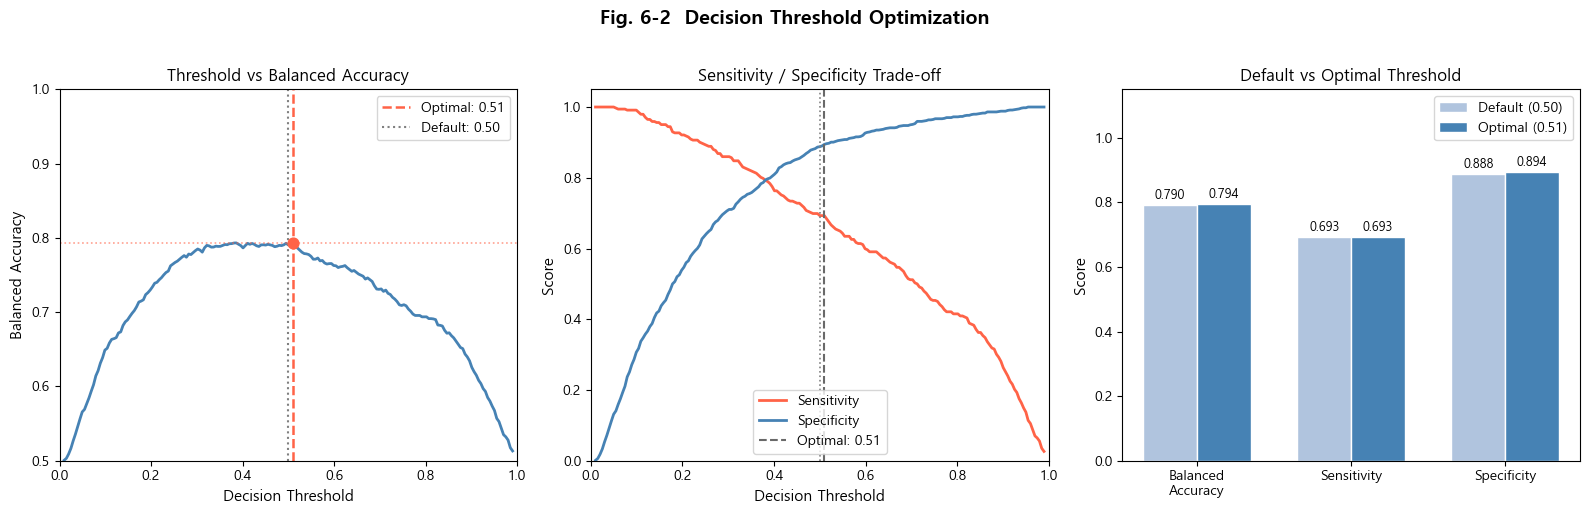

In [30]:
# Fig. 6-2 — 임계값 최적화 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig. 6-2  Decision Threshold Optimization', fontsize=14, fontweight='bold', y=1.02)

# ── 왼쪽: 임계값 vs Balanced Accuracy ──────────────────────
axes[0].plot(thresholds, bal_accs, color='steelblue', lw=2)
axes[0].axvline(best_thr, color='tomato', lw=1.8, ls='--', label=f'Optimal: {best_thr:.2f}')
axes[0].axvline(0.5,      color='gray',   lw=1.5, ls=':',  label='Default: 0.50')
axes[0].axhline(best_bal, color='tomato', lw=1.2, ls=':', alpha=0.6)
axes[0].scatter([best_thr], [best_bal], color='tomato', s=60, zorder=5)
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Balanced Accuracy', fontsize=11)
axes[0].set_title('Threshold vs Balanced Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0.5, 1.0)

# ── 중간: Sensitivity / Specificity Trade-off ─────────────
axes[1].plot(thresholds, sens_list, color='tomato',     lw=2, label='Sensitivity')
axes[1].plot(thresholds, spec_list, color='steelblue',  lw=2, label='Specificity')
axes[1].axvline(best_thr, color='dimgray', lw=1.5, ls='--', label=f'Optimal: {best_thr:.2f}')
axes[1].axvline(0.5,      color='gray',   lw=1.2, ls=':')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Sensitivity / Specificity Trade-off', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.05)

# ── 오른쪽: 기본 vs 최적 임계값 비교 바차트 ─────────────────
metrics  = ['Balanced\nAccuracy', 'Sensitivity', 'Specificity']
vals_05  = [bal_05,   sens_05,   spec_05]
vals_opt = [best_bal, best_sens, best_spec]
x = np.arange(len(metrics)); w = 0.35
b1 = axes[2].bar(x - w/2, vals_05,  w, label='Default (0.50)', color='lightsteelblue', edgecolor='white')
b2 = axes[2].bar(x + w/2, vals_opt, w, label=f'Optimal ({best_thr:.2f})',  color='steelblue',      edgecolor='white')
for bar in list(b1)+list(b2):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_xticks(x); axes[2].set_xticklabels(metrics, fontsize=10)
axes[2].set_ylabel('Score', fontsize=11)
axes[2].set_title('Default vs Optimal Threshold', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

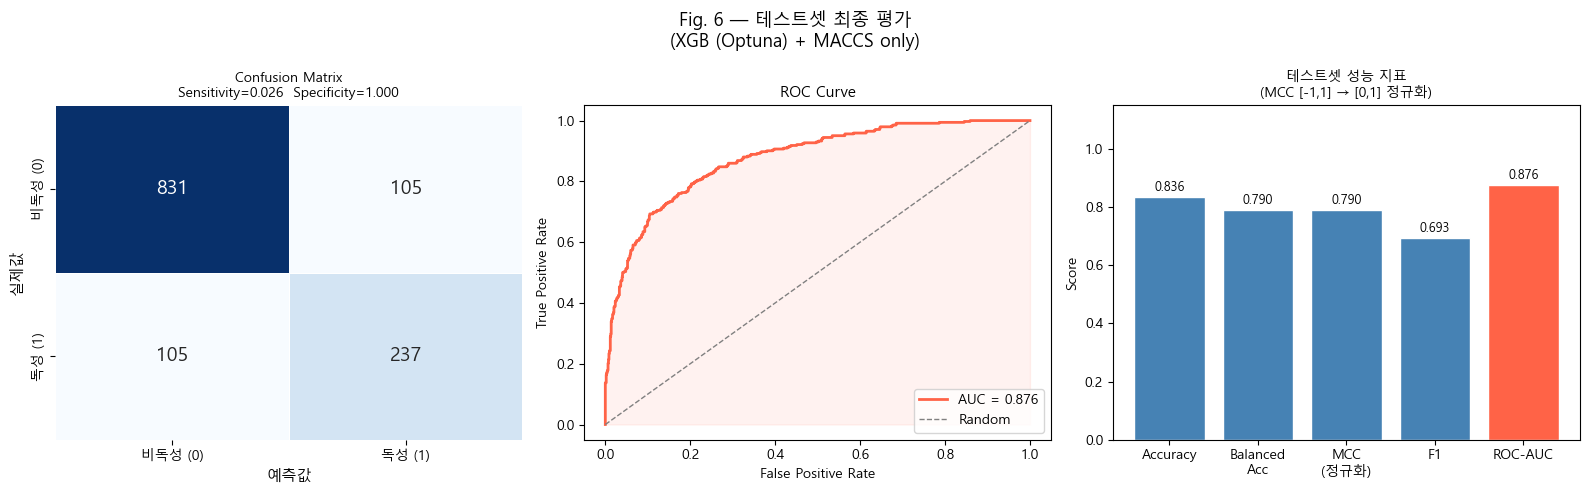

In [31]:
# 테스트셋 성능 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 왼쪽: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['비독성 (0)', '독성 (1)'],
            yticklabels=['비독성 (0)', '독성 (1)'],
            linewidths=0.5, linecolor='white',
            cbar=False, annot_kws={'size': 14})
axes[0].set_xlabel('예측값', fontsize=11)
axes[0].set_ylabel('실제값', fontsize=11)
axes[0].set_title(
    f'Confusion Matrix\nSensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
    fontsize=10)

# 가운데: ROC Curve
axes[1].plot(fpr, tpr, color='tomato', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='tomato')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)

# 오른쪽: 성능 지표 막대
metric_names  = ['Accuracy', 'Balanced\nAcc', 'MCC\n(정규화)', 'F1', 'ROC-AUC']
metric_values = [acc, bal_acc, (mcc + 1) / 2, f1, auc]
bar_colors = ['tomato' if v == max(metric_values) else 'steelblue'
              for v in metric_values]
bars = axes[2].bar(metric_names, metric_values, color=bar_colors, edgecolor='white')
axes[2].set_ylim(0, 1.15)
axes[2].set_ylabel('Score')
axes[2].set_title('테스트셋 성능 지표\n(MCC [-1,1] → [0,1] 정규화)', fontsize=10)
for bar, v in zip(bars, metric_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle(
    f'Fig. 6 — 테스트셋 최종 평가\n({best_mname} + {best_dname})',
    fontsize=13)
plt.tight_layout()
plt.show()

---
## Part B. 회귀 모델 (log10 LD50 예측)

**목표**: log10(LD50) 수치 예측  
**평가 지표**: R² (주), RMSE  
**문헌 기준**: LD50 QSAR에서 R²=0.55~0.65가 일반적 상한 (Roy et al. 2015; Zhu et al. 2009)

### 5-B. 모델 학습 및 5-Fold CV 비교

In [32]:
from sklearn.base import clone

cv_reg = KFold(n_splits=5, shuffle=True)

# 디스크립터 — 개별(5종) + 조합(3종)
# 개별 성능을 먼저 확인하여 조합의 효과를 검증
descriptors_reg = {
    # ── 개별 디스크립터 ──────────────────────────────────────
    'Morgan only'   : X_morgan,
    'MACCS only'    : X_maccs,
    'AtomPair only' : X_ap,
    'Torsion only'  : X_tor,
    'RDKit Desc'    : X_phys_clean,
    # ── 조합 디스크립터 ──────────────────────────────────────
    'All4FP+CleanDesc'  : np.hstack([X_morgan, X_maccs, X_ap, X_tor, X_phys_clean]),
    'All4FP (FP only)'  : np.hstack([X_morgan, X_maccs, X_ap, X_tor]),
    'Morgan+MACCS+Desc' : np.hstack([X_morgan, X_maccs, X_phys_clean]),
}

# 모델 정의 (SVM / MLP / KNN / XGBoost)
models_reg = {
    'SVM'    : Pipeline([('scaler', StandardScaler()),
                          ('reg', SVR(C=1.0, kernel='rbf', epsilon=0.1))]),
    'MLP'    : Pipeline([('scaler', StandardScaler()),
                          ('reg', MLPRegressor(hidden_layer_sizes=(256, 128),
                                               max_iter=500, early_stopping=True))]),
    'KNN'    : Pipeline([('scaler', StandardScaler()),
                          ('reg', KNeighborsRegressor(n_neighbors=7,
                                                       weights='distance', n_jobs=-1))]),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                             subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, verbosity=0),
}

results_reg = []
total = len(descriptors_reg) * len(models_reg); done = 0
for dname, X_d in descriptors_reg.items():
    X_tv = X_d[idx_trainval]
    for mname, model in models_reg.items():
        scores = cross_val_score(model, X_tv, y_reg_tv, cv=cv_reg, scoring='r2')
        results_reg.append({'Descriptor': dname, 'Model': mname,
                             'Mean_R2': scores.mean(), 'Std': scores.std()})
        done += 1
        flag = ' ★' if scores.mean() >= 0.55 else ''
        print(f'[{done:2d}/{total}] {dname:22s} | {mname:8s} | R²={scores.mean():.4f}±{scores.std():.4f}{flag}')

results_reg_df = pd.DataFrame(results_reg).sort_values('Mean_R2', ascending=False).reset_index(drop=True)
print('\n=== Top 5 ===')
print(results_reg_df.head(5).to_string(index=False))


[ 1/32] Morgan only            | SVM      | R²=0.3912±0.0244
[ 2/32] Morgan only            | MLP      | R²=0.2275±0.0563
[ 3/32] Morgan only            | KNN      | R²=0.1030±0.1146
[ 4/32] Morgan only            | XGBoost  | R²=0.4539±0.0173
[ 5/32] MACCS only             | SVM      | R²=0.4631±0.0218
[ 6/32] MACCS only             | MLP      | R²=0.4107±0.0175
[ 7/32] MACCS only             | KNN      | R²=0.4229±0.0467
[ 8/32] MACCS only             | XGBoost  | R²=0.5047±0.0252
[ 9/32] AtomPair only          | SVM      | R²=0.3819±0.0252
[10/32] AtomPair only          | MLP      | R²=0.2440±0.0351
[11/32] AtomPair only          | KNN      | R²=0.3872±0.0321
[12/32] AtomPair only          | XGBoost  | R²=0.4770±0.0316
[13/32] Torsion only           | SVM      | R²=0.3541±0.0442
[14/32] Torsion only           | MLP      | R²=0.2091±0.0272
[15/32] Torsion only           | KNN      | R²=0.3060±0.0066
[16/32] Torsion only           | XGBoost  | R²=0.4062±0.0160
[17/32] RDKit Desc      

### 6-B. Optuna 하이퍼파라미터 최적화 (XGBoost)


In [33]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

top_desc_name = results_reg_df.iloc[0]['Descriptor']
X_optuna_tv   = descriptors_reg[top_desc_name][idx_trainval]

def xgb_obj(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'       : trial.suggest_int('max_depth', 4, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'n_jobs': -1, 'verbosity': 0,
    }
    return cross_val_score(XGBRegressor(**params), X_optuna_tv, y_reg_tv,
                           cv=cv_reg, scoring='r2').mean()

print('XGBoost Optuna 최적화 중 (25 trials)...')
study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler())
study_xgb.optimize(xgb_obj, n_trials=25)
best_xgb_params = {**study_xgb.best_params, 'n_jobs': -1, 'verbosity': 0}
print(f'  XGB 최적 R²: {study_xgb.best_value:.4f}')
print(f'  최적 파라미터: {study_xgb.best_params}')

# results_reg_df에 추가
optuna_rows = [{'Descriptor': 'All4FP+CleanDesc', 'Model': 'XGB (Optuna)',
                'Mean_R2': study_xgb.best_value, 'Std': 0.0}]
results_reg_df = pd.concat([results_reg_df, pd.DataFrame(optuna_rows)],
    ignore_index=True).sort_values('Mean_R2', ascending=False).reset_index(drop=True)
print(f'\n최고 CV R² = {results_reg_df.iloc[0]["Mean_R2"]:.4f}')


XGBoost Optuna 최적화 중 (25 trials)...
  XGB 최적 R²: 0.5573
  최적 파라미터: {'n_estimators': 635, 'max_depth': 10, 'learning_rate': 0.023923820167019275, 'subsample': 0.7179934791978838, 'colsample_bytree': 0.9869606852552483, 'reg_alpha': 0.010095413000300967, 'reg_lambda': 4.553490011827442}

최고 CV R² = 0.5573


### 7-B. 최고 성능 모델 — 테스트셋 평가

In [34]:
from sklearn.base import clone

best_row_reg   = results_reg_df.iloc[0]
best_dname_reg = best_row_reg['Descriptor']
best_mname_reg = best_row_reg['Model']

print(f'최고 CV: {best_dname_reg} + {best_mname_reg}  (R²={best_row_reg["Mean_R2"]:.4f})')

# Optuna 최적 파라미터 반영 or 기존 모델 clone
if best_mname_reg == 'XGB (Optuna)':
    final_reg = XGBRegressor(**best_xgb_params)
else:
    final_reg = clone(models_reg[best_mname_reg])

final_reg.fit(descriptors_reg[best_dname_reg][idx_trainval], y_reg_tv)
y_pred_reg = final_reg.predict(descriptors_reg[best_dname_reg][idx_test])

r2   = r2_score(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
print(f'\nTest R²  : {r2:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'문헌 기준 (LD50 QSAR R²=0.55~0.65) 대비: {"달성" if r2>=0.55 else "미달"}')


최고 CV: All4FP+CleanDesc + XGB (Optuna)  (R²=0.5573)

Test R²  : 0.5618
Test RMSE: 0.5650
문헌 기준 (LD50 QSAR R²=0.55~0.65) 대비: 달성


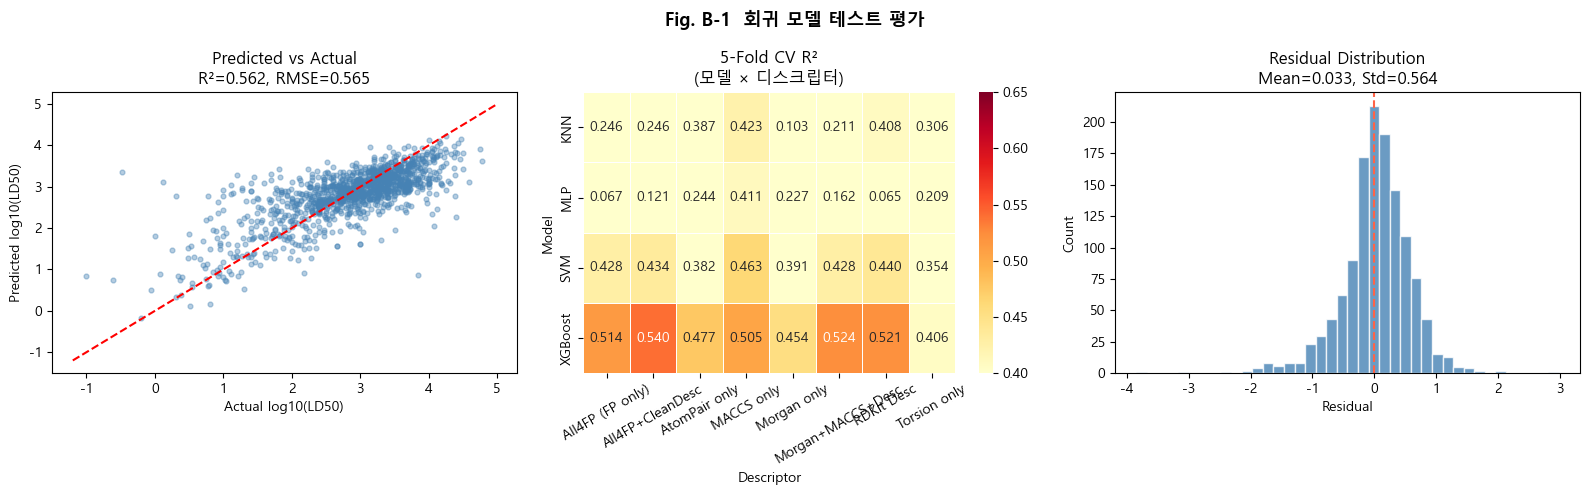

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mn = min(y_reg_test.min(), y_pred_reg.min()) - 0.2
mx = max(y_reg_test.max(), y_pred_reg.max()) + 0.2

axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.4, s=12, color='steelblue')
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5)
axes[0].set_xlabel('Actual log10(LD50)'); axes[0].set_ylabel('Predicted log10(LD50)')
axes[0].set_title(f'Predicted vs Actual\nR²={r2:.3f}, RMSE={rmse:.3f}')

# R² 히트맵
pivot_reg = results_reg_df[results_reg_df['Model'].isin(list(models_reg.keys()))].pivot_table(
    index='Model', columns='Descriptor', values='Mean_R2')
sns.heatmap(pivot_reg, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.4, vmax=0.65,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('5-Fold CV R²\n(모델 × 디스크립터)')
axes[1].tick_params(axis='x', rotation=30)

# 잔차 히스토그램
residuals = y_reg_test - y_pred_reg
axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='tomato', lw=1.5, ls='--')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution\nMean={residuals.mean():.3f}, Std={residuals.std():.3f}')

plt.suptitle('Fig. B-1  회귀 모델 테스트 평가', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. 실험 결과 저장 & 최고 모델 저장

**출력 파일**:
- `experiment_results.csv` — 분류 + 회귀 전체 CV 결과
- `experiment_best.csv` — 모델 종류별 최고 성능
- `model_best.joblib` — 최고 분류 모델 (feature pipeline 포함)

In [36]:
# ── experiment_results.csv ──────────────────────────────────────────────
results_clf_df['Task'] = 'Classification'
results_clf_df['Metric'] = 'Balanced Accuracy'
results_clf_df.rename(columns={'Mean_BalAcc': 'Mean_Score'}, inplace=True)

results_reg_df['Task'] = 'Regression'
results_reg_df['Metric'] = 'R2'
results_reg_df.rename(columns={'Mean_R2': 'Mean_Score'}, inplace=True)

all_results = pd.concat([results_clf_df, results_reg_df], ignore_index=True)
all_results.to_csv('experiment_results.csv', index=False)
print(f'experiment_results.csv 저장: {len(all_results)}행')

# ── experiment_best.csv ──────────────────────────────────────────────────
best_per_model = all_results.loc[all_results.groupby(['Task','Model'])['Mean_Score'].idxmax()]
best_per_model = best_per_model.sort_values(['Task','Mean_Score'], ascending=[True,False])
best_per_model.to_csv('experiment_best.csv', index=False)
print(f'experiment_best.csv 저장: {len(best_per_model)}행')
print(best_per_model[['Task','Model','Descriptor','Mean_Score']].to_string(index=False))

experiment_results.csv 저장: 89행
experiment_best.csv 저장: 13행
          Task               Model        Descriptor  Mean_Score
Classification        XGB (Optuna)        MACCS only    0.770034
Classification                 SVM        MACCS only    0.766578
Classification ExtraTrees (Optuna)        MACCS only    0.763137
Classification             XGBoost        MACCS only    0.762985
Classification          ExtraTrees Morgan+MACCS+Desc    0.752935
Classification       HistGradBoost Morgan+MACCS+Desc    0.732249
Classification                 KNN        MACCS only    0.717710
Classification                 MLP        MACCS only    0.713887
    Regression        XGB (Optuna)  All4FP+CleanDesc    0.557335
    Regression             XGBoost  All4FP+CleanDesc    0.540451
    Regression                 SVM        MACCS only    0.463073
    Regression                 KNN        MACCS only    0.422905
    Regression                 MLP        MACCS only    0.410664


In [37]:
# ── model_best.joblib ───────────────────────────────────────────────────
use_ap   = 'AP'   in best_dname_clf
use_tor  = 'Tor'  in best_dname_clf
use_phys = 'Desc' in best_dname_clf

save_dict = {
    'task'              : 'binary_classification',
    'dataset'           : 'NTP ICE Acute Oral',
    'best_descriptor'   : best_dname_clf,
    'best_model_name'   : best_mname_clf,
    'model'             : final_clf,
    'var_selector'      : var_sel,
    'corr_keep_cols'    : keep_cols,
    'use_ap'            : use_ap,
    'use_tor'           : use_tor,
    'use_phys'          : use_phys,
    'optimal_threshold' : best_thr,
    'test_metrics'      : {
        'balanced_accuracy' : bal_acc,
        'roc_auc'           : roc_auc,
        'sensitivity'       : sens,
        'specificity'       : spec,
    },
}
joblib.dump(save_dict, 'model_best.joblib')
print('model_best.joblib 저장 완료')
print(f'  모델: {best_mname_clf}  /  디스크립터: {best_dname_clf}')
print(f'  AP={use_ap}, Tor={use_tor}, Desc={use_phys}, threshold={best_thr:.3f}')
print(f'  Test BalAcc={bal_acc:.4f}, ROC-AUC={roc_auc:.4f}')


model_best.joblib 저장 완료
  모델: XGB (Optuna)  /  디스크립터: MACCS only
  AP=False, Tor=False, Desc=False, threshold=0.510
  Test BalAcc=0.7904, ROC-AUC=0.8760


## 9. 새 분자 예측 예시

저장된 모델을 로드하여 새로운 SMILES를 입력하면 독성을 예측할 수 있습니다.

In [39]:
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from rdkit.Chem import rdMolDescriptors

loaded       = joblib.load('model_best.joblib')
model_loaded = loaded['model']
var_sel_l    = loaded['var_selector']
keep_cols_l  = loaded['corr_keep_cols']
opt_thr      = loaded['optimal_threshold']
best_desc_l  = loaded['best_descriptor']

print(f'로드: {loaded["best_model_name"]} | {best_desc_l}')
print(f'thr={opt_thr:.3f}')

def predict_toxicity(smiles_list):
    """SMILES 리스트 → 독성 예측 (1=독성, 0=비독성)"""
    use_morgan = 'Morgan' in best_desc_l
    use_maccs  = 'MACCS'  in best_desc_l
    use_ap     = 'AP'     in best_desc_l or 'AtomPair' in best_desc_l
    use_tor    = 'Tor'    in best_desc_l or 'Torsion'  in best_desc_l
    use_phys   = 'Desc'   in best_desc_l

    # 단일 디스크립터 키워드 처리
    if best_desc_l == 'Morgan only':
        use_morgan = True
    elif best_desc_l == 'MACCS only':
        use_maccs = True
    elif best_desc_l == 'AtomPair only':
        use_ap = True
    elif best_desc_l == 'Torsion only':
        use_tor = True
    elif best_desc_l == 'RDKit Desc':
        use_phys = True

    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            results.append({'SMILES': smi, 'Label': 'Invalid SMILES'})
            continue

        parts = []
        if use_morgan:
            parts.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)))
        if use_maccs:
            parts.append(np.array(MACCSkeys.GenMACCSKeys(mol)))
        if use_ap:
            parts.append(np.array(rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=2048)))
        if use_tor:
            parts.append(np.array(rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=2048)))
        if use_phys:
            raw = []
            for _, fn in Descriptors.descList:
                try:
                    v = float(fn(mol))
                    raw.append(v if np.isfinite(v) else 0.0)
                except:
                    raw.append(0.0)
            clean = var_sel_l.transform(np.array(raw).reshape(1,-1))[0][keep_cols_l]
            parts.append(clean)

        X_new = np.hstack(parts).reshape(1, -1)

        # 피처 수 불일치 안전장치
        n_exp = model_loaded.n_features_in_
        if X_new.shape[1] != n_exp:
            print(f'[경고] {smi}: 피처 수 불일치 ({X_new.shape[1]} vs {n_exp}), 조정 중...')
            if X_new.shape[1] > n_exp:
                X_new = X_new[:, :n_exp]
            else:
                X_new = np.pad(X_new, ((0,0),(0, n_exp - X_new.shape[1])))

        proba = model_loaded.predict_proba(X_new)[0, 1]
        pred  = int(proba >= opt_thr)
        label = '독성 (LD50 ≤ 300 mg/kg)' if pred == 1 else '비독성 (LD50 > 300 mg/kg)'
        results.append({'SMILES': smi, 'Prob_Toxic': round(proba, 4),
                        'Prediction': pred, 'Label': label})
    return pd.DataFrame(results)

# 테스트 (Aspirin / Caffeine / Chloroform)
test_smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',
    'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
    'ClC(Cl)Cl',
]
print(predict_toxicity(test_smiles).to_string(index=False))

로드: XGB (Optuna) | MACCS only
thr=0.510
                    SMILES  Prob_Toxic  Prediction                  Label
     CC(=O)Oc1ccccc1C(=O)O      0.1306           0 비독성 (LD50 > 300 mg/kg)
Cn1cnc2c1c(=O)n(C)c(=O)n2C      0.4851           0 비독성 (LD50 > 300 mg/kg)
                 ClC(Cl)Cl      0.5423           1  독성 (LD50 ≤ 300 mg/kg)


---
## 🎁 가산점 신청 (선택)

| 항목 | 시도 여부 | 관련 셀 |
|---|---|---|
| A. 알고리즘 다양성 (4종) | ✅ | 섹션 5-A, 5-B |
| B. Hyperparameter 탐색 (Optuna) | ✅ | 섹션 6-B |
| C. 모델 성능 평가 (BalAcc, ROC-AUC, R², RMSE) | ✅ | 섹션 7-A, 7-B |
| D. 모델 개발 과정 시각화 & 설명 | ✅ | Fig. A-1, Fig. A-2, Fig. B-1 |